In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from pathlib import Path
import pickle
import pandas as pd

from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

In [ ]:
DATA_DIR = Path("data")
PROCESSED_DIR = DATA_DIR / "processed"
SPLIT_DIR = DATA_DIR / "splits"  

NUM_CLASSES = 36
WINDOW_SIZE = 65
IGNORE_INDEX = -100

device = torch.device("mps")


device

device(type='mps')

In [6]:
train_path = PROCESSED_DIR / "train_windows_65.pkl"
val_path = PROCESSED_DIR / "val_windows_65.pkl"
test_path = PROCESSED_DIR / "test_windows_65.pkl"

with open(train_path, "rb") as f:
    train_windows = pickle.load(f)

with open(val_path, "rb") as f:
    val_windows = pickle.load(f)

with open(test_path, "rb") as f:
    test_windows = pickle.load(f)

print(len(train_windows), len(val_windows), len(test_windows))

929004 113997 118229


In [4]:
FEATURE_COLUMNS = [
    "resname",
    "polarity_group",
    "hydropathy_group",
    "volume_group",
    "chemical_group",
    "physicochemical_group",
    "charge_group",
    "hydrogen_donor_acceptor_group",
]

WINDOW_SIZE = 65
IGNORE_INDEX = -100

In [7]:
PAD_TOKEN = "PAD"
UNK_TOKEN = "UNK"

cat_to_idx = {}

for col in FEATURE_COLUMNS:
    values = set()

    for sample in train_windows:
        for residue_features in sample["features"]:
            values.add(residue_features[col])

    values = sorted(values)

    vocab = [PAD_TOKEN, UNK_TOKEN]
    for value in values:
        if value not in vocab:
            vocab.append(value)

    cat_to_idx[col] = {value: idx for idx, value in enumerate(vocab)}

In [10]:
train_dataset = Chi1WindowDataset(
    samples=train_windows,
    feature_columns=FEATURE_COLUMNS,
    cat_to_idx=cat_to_idx,
)

val_dataset = Chi1WindowDataset(
    samples=val_windows,
    feature_columns=FEATURE_COLUMNS,
    cat_to_idx=cat_to_idx,
)

test_dataset = Chi1WindowDataset(
    samples=test_windows,
    feature_columns=FEATURE_COLUMNS,
    cat_to_idx=cat_to_idx,
)

In [11]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

test_loader_first = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

In [9]:
class Chi1WindowDataset(Dataset):
    def __init__(self, samples, feature_columns, cat_to_idx):
        self.samples = samples
        self.feature_columns = feature_columns
        self.cat_to_idx = cat_to_idx

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        x_cat = []

        for residue_features in sample["features"]:
            row = []

            for col in self.feature_columns:
                value = residue_features[col]

                encoded_value = self.cat_to_idx[col].get(
                    value,
                    self.cat_to_idx[col][UNK_TOKEN],
                )

                row.append(encoded_value)

            x_cat.append(row)

        x_cat = torch.tensor(x_cat, dtype=torch.long)
        y = torch.tensor(sample["targets"], dtype=torch.long)
        target_mask = torch.tensor(sample["target_mask"], dtype=torch.bool)
        padding_mask = torch.tensor(sample["padding_mask"], dtype=torch.bool)

        return {
            "x_cat": x_cat,
            "y": y,
            "target_mask": target_mask,
            "padding_mask": padding_mask,
            "pdb_id": sample["pdb_id"],
            "chain_id": sample["chain_id"],
            "center_residue_number": sample["center_residue_number"],
            "center_resname": sample["center_resname"],
        }

In [12]:
class Chi1Transformer(nn.Module):
    def __init__(
        self,
        cat_vocab_sizes,
        cat_embedding_dims,
        d_model=128,
        nhead=8,
        num_layers=4,
        dim_feedforward=256,
        dropout=0.1,
        num_classes=36,
        window_size=65,
    ):
        super().__init__()

        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(
                num_embeddings=vocab_size,
                embedding_dim=emb_dim,
                padding_idx=0,
            )
            for vocab_size, emb_dim in zip(cat_vocab_sizes, cat_embedding_dims)
        ])

        total_cat_dim = sum(cat_embedding_dims)

        self.input_projection = nn.Sequential(
            nn.Linear(total_cat_dim, d_model),
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
        )

        self.position_embedding = nn.Embedding(window_size, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=num_layers,
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, x_cat, padding_mask=None):
        batch_size, seq_len, num_features = x_cat.shape

        embedded_features = []

        for feature_idx, embedding_layer in enumerate(self.cat_embeddings):
            feature_values = x_cat[:, :, feature_idx]
            feature_emb = embedding_layer(feature_values)
            embedded_features.append(feature_emb)

        x = torch.cat(embedded_features, dim=-1)
        x = self.input_projection(x)

        positions = torch.arange(seq_len, device=x.device)
        positions = positions.unsqueeze(0).expand(batch_size, seq_len)

        x = x + self.position_embedding(positions)

        x = self.encoder(
            x,
            src_key_padding_mask=padding_mask,
        )

        logits = self.classifier(x)

        return logits

In [14]:
cat_vocab_sizes = [len(cat_to_idx[col]) for col in FEATURE_COLUMNS]

cat_embedding_dims = [
    min(32, max(4, vocab_size // 2))
    for vocab_size in cat_vocab_sizes
]

print("Vocab sizes:", cat_vocab_sizes)
print("Embedding dims:", cat_embedding_dims)

Vocab sizes: [22, 4, 5, 6, 13, 11, 6, 6]
Embedding dims: [11, 4, 4, 4, 6, 5, 4, 4]


In [15]:
model = Chi1Transformer(
    cat_vocab_sizes=cat_vocab_sizes,
    cat_embedding_dims=cat_embedding_dims,
    d_model=128,
    nhead=8,
    num_layers=4,
    dim_feedforward=256,
    dropout=0.1,
    num_classes=NUM_CLASSES,
    window_size=WINDOW_SIZE,
).to(device)

/opt/anaconda3/lib/python3.12/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [16]:
def circular_bin_distance(pred_bins, true_bins, num_bins=36):
    diff = torch.abs(pred_bins - true_bins)
    return torch.minimum(diff, num_bins - diff)

In [ ]:
def collect_diagnostics_first_model(
    model,
    loader,
    device,
    metric="exact",
    num_classes=36,
    num_probability_samples=25,
):
    model.eval()

    window_accuracies = []

    position_correct = None
    position_total = None

    probability_curves = []

    with torch.no_grad():
        for batch in loader:
            x_cat = batch["x_cat"].to(device)
            y = batch["y"].to(device)
            target_mask = batch["target_mask"].to(device)
            padding_mask = batch["padding_mask"].to(device)

            logits = model(
                x_cat=x_cat,
                padding_mask=padding_mask,
            )

            probs = torch.softmax(logits, dim=-1)
            preds = torch.argmax(logits, dim=-1)

            valid_mask = target_mask & (y != -100)

            batch_size, seq_len = y.shape

            if position_correct is None:
                position_correct = np.zeros(seq_len, dtype=np.float64)
                position_total = np.zeros(seq_len, dtype=np.float64)

            for pos in range(seq_len):
                valid_pos = valid_mask[:, pos]

                if valid_pos.sum().item() == 0:
                    continue

                pred_pos = preds[:, pos][valid_pos]
                true_pos = y[:, pos][valid_pos]

                if metric == "exact":
                    correct = (pred_pos == true_pos)
                elif metric == "pm1":
                    correct = circular_bin_distance(pred_pos, true_pos, num_bins=num_classes) <= 1
                elif metric == "pm3":
                    correct = circular_bin_distance(pred_pos, true_pos, num_bins=num_classes) <= 3
                else:
                    raise ValueError("metric must be 'exact', 'pm1' or 'pm3'")

                position_correct[pos] += correct.sum().item()
                position_total[pos] += valid_pos.sum().item()

            # Accuracy по каждому окну
            for i in range(batch_size):
                valid_i = valid_mask[i]

                if valid_i.sum().item() == 0:
                    continue

                pred_i = preds[i][valid_i]
                true_i = y[i][valid_i]

                if metric == "exact":
                    correct_i = (pred_i == true_i).float()
                elif metric == "pm1":
                    correct_i = (circular_bin_distance(pred_i, true_i, num_bins=num_classes) <= 1).float()
                elif metric == "pm3":
                    correct_i = (circular_bin_distance(pred_i, true_i, num_bins=num_classes) <= 3).float()

                window_acc = correct_i.mean().item()
                window_accuracies.append(window_acc)

            if len(probability_curves) < num_probability_samples:
                center_idx = seq_len // 2

                for i in range(batch_size):
                    if len(probability_curves) >= num_probability_samples:
                        break

                    if valid_mask[i, center_idx]:
                        probability_curves.append(
                            probs[i, center_idx].detach().cpu().numpy()
                        )
                    else:
                        valid_positions = torch.where(valid_mask[i])[0]
                        if len(valid_positions) > 0:
                            pos = valid_positions[0].item()
                            probability_curves.append(
                                probs[i, pos].detach().cpu().numpy()
                            )

    position_accuracy = np.divide(
        position_correct,
        position_total,
        out=np.zeros_like(position_correct),
        where=position_total > 0
    )

    return {
        "window_accuracies": np.array(window_accuracies),
        "position_accuracy": position_accuracy,
        "position_total": position_total,
        "probability_curves": probability_curves,
    }

In [18]:
def collect_diagnostics_best_model(
    model,
    loader,
    device,
    metric="exact",
    num_classes=36,
    num_probability_samples=25,
):
    model.eval()

    window_accuracies = []

    position_correct = None
    position_total = None

    probability_curves = []

    with torch.no_grad():
        for batch in loader:
            x_cat = batch["x_cat"].to(device)
            x_num = batch["x_num"].to(device)
            distance_matrix = batch["distance_matrix"].to(device)

            y = batch["y"].to(device)
            target_mask = batch["target_mask"].to(device)
            padding_mask = batch["padding_mask"].to(device)

            output = model(
                x_cat=x_cat,
                x_num=x_num,
                distance_matrix=distance_matrix,
                padding_mask=padding_mask,
                return_coarse=False,
            )

            if isinstance(output, tuple):
                logits = output[0]
            else:
                logits = output

            probs = torch.softmax(logits, dim=-1)
            preds = torch.argmax(logits, dim=-1)

            valid_mask = target_mask & (y != -100)

            batch_size, seq_len = y.shape

            if position_correct is None:
                position_correct = np.zeros(seq_len, dtype=np.float64)
                position_total = np.zeros(seq_len, dtype=np.float64)

            # Accuracy по позициям окна
            for pos in range(seq_len):
                valid_pos = valid_mask[:, pos]

                if valid_pos.sum().item() == 0:
                    continue

                pred_pos = preds[:, pos][valid_pos]
                true_pos = y[:, pos][valid_pos]

                if metric == "exact":
                    correct = (pred_pos == true_pos)
                elif metric == "pm1":
                    correct = circular_bin_distance(pred_pos, true_pos, num_bins=num_classes) <= 1
                elif metric == "pm3":
                    correct = circular_bin_distance(pred_pos, true_pos, num_bins=num_classes) <= 3
                else:
                    raise ValueError("metric must be 'exact', 'pm1' or 'pm3'")

                position_correct[pos] += correct.sum().item()
                position_total[pos] += valid_pos.sum().item()

            # Accuracy по каждому окну
            for i in range(batch_size):
                valid_i = valid_mask[i]

                if valid_i.sum().item() == 0:
                    continue

                pred_i = preds[i][valid_i]
                true_i = y[i][valid_i]

                if metric == "exact":
                    correct_i = (pred_i == true_i).float()
                elif metric == "pm1":
                    correct_i = (circular_bin_distance(pred_i, true_i, num_bins=num_classes) <= 1).float()
                elif metric == "pm3":
                    correct_i = (circular_bin_distance(pred_i, true_i, num_bins=num_classes) <= 3).float()

                window_acc = correct_i.mean().item()
                window_accuracies.append(window_acc)

            # Вероятности для нескольких примеров
            if len(probability_curves) < num_probability_samples:
                center_idx = seq_len // 2

                for i in range(batch_size):
                    if len(probability_curves) >= num_probability_samples:
                        break

                    if valid_mask[i, center_idx]:
                        probability_curves.append(
                            probs[i, center_idx].detach().cpu().numpy()
                        )
                    else:
                        valid_positions = torch.where(valid_mask[i])[0]
                        if len(valid_positions) > 0:
                            pos = valid_positions[0].item()
                            probability_curves.append(
                                probs[i, pos].detach().cpu().numpy()
                            )

    position_accuracy = np.divide(
        position_correct,
        position_total,
        out=np.zeros_like(position_correct),
        where=position_total > 0
    )

    return {
        "window_accuracies": np.array(window_accuracies),
        "position_accuracy": position_accuracy,
        "position_total": position_total,
        "probability_curves": probability_curves,
    }

In [19]:
def plot_model_diagnostics(
    diagnostics,
    model_name,
    metric_name="Exact accuracy",
    save_prefix=None,
):
    window_accuracies = diagnostics["window_accuracies"]
    position_accuracy = diagnostics["position_accuracy"]
    probability_curves = diagnostics["probability_curves"]

    # --- 1. Histogram ---
    plt.figure(figsize=(10, 5))
    plt.hist(window_accuracies, bins=50)
    plt.xlabel(metric_name)
    plt.ylabel("Count")
    plt.title(f"Rotamer accuracy for {model_name}")
    if save_prefix is not None:
        plt.savefig(f"{save_prefix}_hist.png", dpi=300, bbox_inches="tight")
    plt.show()

    # --- 2. Accuracy by position ---
    plt.figure(figsize=(12, 5))
    plt.bar(np.arange(len(position_accuracy)), position_accuracy)
    plt.xlabel("Position in window")
    plt.ylabel(metric_name)
    plt.title(f"Rotamer accuracy by window position for {model_name}")
    if save_prefix is not None:
        plt.savefig(f"{save_prefix}_position_accuracy.png", dpi=300, bbox_inches="tight")
    plt.show()

    # --- 3. Probability curves ---
    plt.figure(figsize=(12, 5))
    for curve in probability_curves:
        plt.plot(np.arange(len(curve)), curve, alpha=0.8)

    plt.xlabel("Chi1 bin")
    plt.ylabel("Predicted probability")
    plt.title(f"Predicted probabilities for samples of {model_name}")
    if save_prefix is not None:
        plt.savefig(f"{save_prefix}_probabilities.png", dpi=300, bbox_inches="tight")
    plt.show()

In [20]:
 first_checkpoint_path = PROCESSED_DIR / "best_chi1_transformer.pt"

checkpoint = torch.load(
    first_checkpoint_path,
    map_location=device,
)

first_model = Chi1Transformer(
    cat_vocab_sizes=checkpoint["cat_vocab_sizes"],
    cat_embedding_dims=checkpoint["cat_embedding_dims"],
    d_model=checkpoint["model_config"]["d_model"],
    nhead=checkpoint["model_config"]["nhead"],
    num_layers=checkpoint["model_config"]["num_layers"],
    dim_feedforward=checkpoint["model_config"]["dim_feedforward"],
    dropout=checkpoint["model_config"]["dropout"],
    num_classes=checkpoint["model_config"]["num_classes"],
    window_size=checkpoint["model_config"]["window_size"],
).to(device)

first_model.load_state_dict(checkpoint["model_state_dict"])
first_model.eval()

/var/folders/j3/qr5mg5rj55j5lf7yh978r__80000gn/T/ipykernel_12562/3029555896.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


Chi1Transformer(
  (cat_embeddings): ModuleList(
    (0): Embedding(22, 11, padding_idx=0)
    (1): Embedding(4, 4, padding_idx=0)
    (2): Embedding(5, 4, padding_idx=0)
    (3): Embedding(6, 4, padding_idx=0)
    (4): Embedding(13, 6, padding_idx=0)
    (5): Embedding(11, 5, padding_idx=0)
    (6-7): 2 x Embedding(6, 4, padding_idx=0)
  )
  (input_projection): Sequential(
    (0): Linear(in_features=42, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): Dropout(p=0.1, inplace=False)
  )
  (position_embedding): Embedding(65, 128)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=25

In [ ]:
first_model_diagnostics = collect_diagnostics_first_model(
    model=first_model,
    loader=test_loader_first,
    device=device,
    metric="exact",
    num_probability_samples=25,
)

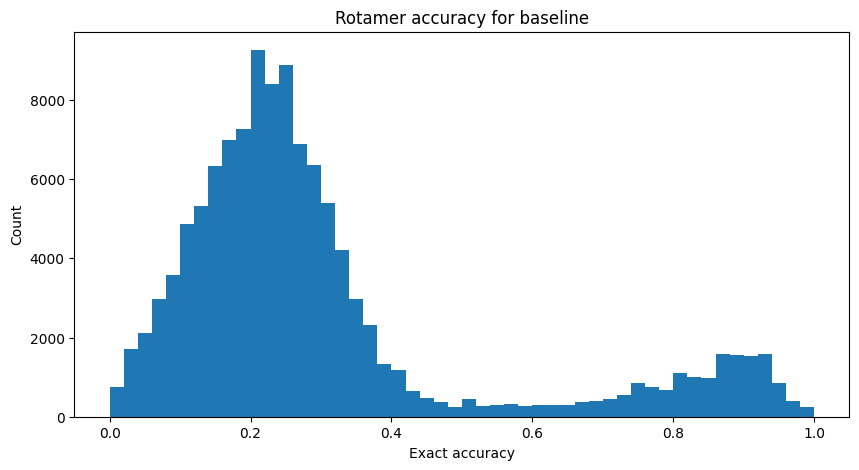

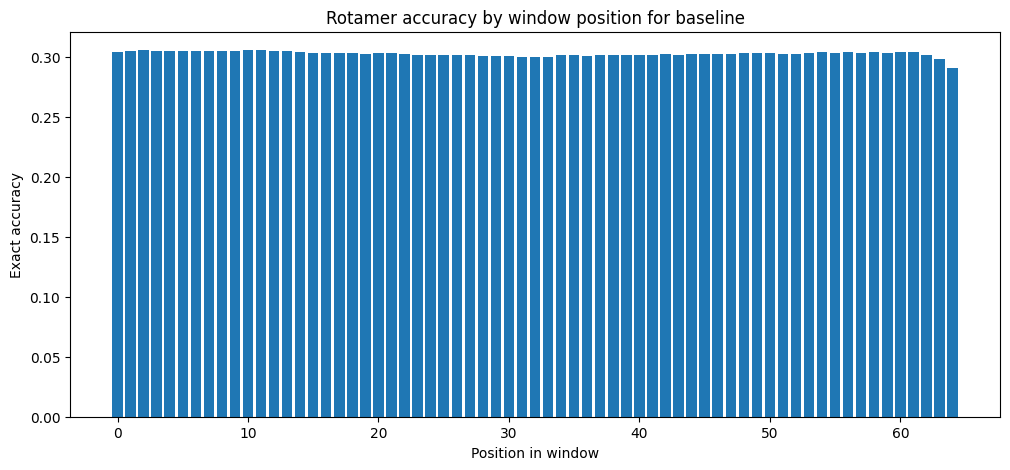

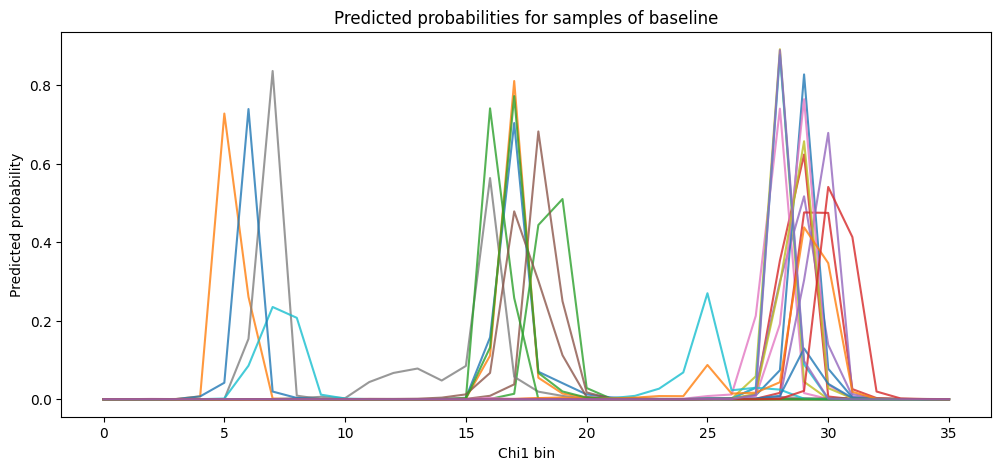

In [40]:
plot_model_diagnostics(
    diagnostics=first_model_diagnostics,
    model_name="baseline",
    metric_name="Exact accuracy",
    save_prefix="nn1_first_model",
)

In [25]:
DATA_DIR = Path("data")
PROCESSED_DIR = DATA_DIR / "processed"

residue_path = PROCESSED_DIR / "chi1_residue_level_dataset_with_backbone.csv"

residue_df = pd.read_csv(residue_path)

residue_df.head()

/var/folders/j3/qr5mg5rj55j5lf7yh978r__80000gn/T/ipykernel_12562/2338238424.py:6: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  residue_df = pd.read_csv(residue_path)


,pdb_id,chain_id,residue_number,insertion_code,resname,chi1_angle,chi1_bin_10deg,target_mask,phi_angle,psi_angle,...,ca_y,ca_z,has_ca,polarity_group,hydropathy_group,volume_group,chemical_group,physicochemical_group,charge_group,hydrogen_donor_acceptor_group
0,2BO5,A,1,NaN,PHE,267.667646,26,1,NaN,181.918425,...,12.444,24.544001,1,nonpolar,hydrophobic,large,aromatic,aromatic,neutral,none
1,2BO5,A,2,NaN,ALA,NaN,-100,0,60.562806,33.116558,...,11.484,21.757999,1,nonpolar,hydrophobic,small,aliphatic,nonpolar_aliphatic,neutral,none
2,2BO5,A,3,NaN,LYS,270.463347,27,1,299.348529,285.420907,...,9.539,24.302000,1,polar,hydrophilic,large,basic,positive,positive,donor
3,2BO5,A,4,NaN,LEU,314.589093,31,1,61.046673,156.017583,...,9.970,22.927000,1,nonpolar,hydrophobic,large,aliphatic,nonpolar_aliphatic,neutral,none
4,2BO5,A,5,NaN,VAL,286.087049,28,1,248.450014,326.412570,...,7.605,23.750000,1,nonpolar,hydrophobic,medium,aliphatic,nonpolar_aliphatic,neutral,none


In [26]:

residue_path = PROCESSED_DIR / "chi1_residue_level_dataset_with_backbone.csv"

residue_df = pd.read_csv(residue_path)

SPLIT_DIR = DATA_DIR / "splits"

train_pdb_ids = set(pd.read_csv(SPLIT_DIR / "train_pdb_ids.csv")["pdb_id"])
val_pdb_ids = set(pd.read_csv(SPLIT_DIR / "val_pdb_ids.csv")["pdb_id"])
test_pdb_ids = set(pd.read_csv(SPLIT_DIR / "test_pdb_ids.csv")["pdb_id"])

train_residue_df = residue_df[residue_df["pdb_id"].isin(train_pdb_ids)].copy()
val_residue_df = residue_df[residue_df["pdb_id"].isin(val_pdb_ids)].copy()
test_residue_df = residue_df[residue_df["pdb_id"].isin(test_pdb_ids)].copy()

print(train_residue_df.shape)
print(val_residue_df.shape)
print(test_residue_df.shape)

/var/folders/j3/qr5mg5rj55j5lf7yh978r__80000gn/T/ipykernel_12562/601228350.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  residue_df = pd.read_csv(residue_path)


(929004, 27)
(113997, 27)
(118229, 27)


In [27]:
ID_COLUMNS = [
    "pdb_id",
    "chain_id",
    "residue_number",
    "insertion_code",
]

FEATURE_COLUMNS = [
    "resname",
    "polarity_group",
    "hydropathy_group",
    "volume_group",
    "chemical_group",
    "physicochemical_group",
    "charge_group",
    "hydrogen_donor_acceptor_group",
]

TARGET_COLUMN = "chi1_bin_10deg"
MASK_COLUMN = "target_mask"

WINDOW_SIZE = 65
CONTEXT_RADIUS = WINDOW_SIZE // 2

PAD_TOKEN = "PAD"
IGNORE_INDEX = -100

NUMERIC_FEATURE_COLUMNS = [
    "phi_sin",
    "phi_cos",
    "psi_sin",
    "psi_cos",
    "has_phi",
    "has_psi",
    "relative_position",
]

DISTANCE_NORMALIZATION = 30.0

In [28]:
residue_df = pd.read_csv(PROCESSED_DIR / "chi1_residue_level_dataset_with_backbone_prepared.csv")

residue_df.head()

/var/folders/j3/qr5mg5rj55j5lf7yh978r__80000gn/T/ipykernel_12562/3200113578.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  residue_df = pd.read_csv(PROCESSED_DIR / "chi1_residue_level_dataset_with_backbone_prepared.csv")


,pdb_id,chain_id,residue_number,insertion_code,resname,chi1_angle,chi1_bin_10deg,target_mask,phi_angle,psi_angle,...,ca_y,ca_z,has_ca,polarity_group,hydropathy_group,volume_group,chemical_group,physicochemical_group,charge_group,hydrogen_donor_acceptor_group
0,133L,A,1,NaN,LYS,72.602035,7,1,NaN,151.664947,...,20.433001,21.160000,1,polar,hydrophilic,large,basic,positive,positive,donor
1,133L,A,2,NaN,VAL,184.764731,18,1,254.529890,114.762469,...,19.736000,18.659000,1,nonpolar,hydrophobic,medium,aliphatic,nonpolar_aliphatic,neutral,none
2,133L,A,3,NaN,PHE,279.004006,27,1,286.350988,150.684206,...,22.340000,18.976999,1,nonpolar,hydrophobic,large,aromatic,aromatic,neutral,none
3,133L,A,4,NaN,GLU,284.236970,28,1,273.982337,158.728892,...,23.539000,16.051001,1,polar,hydrophilic,large,acidic,negative,negative,acceptor
4,133L,A,5,NaN,ARG,188.255005,18,1,305.536639,301.401648,...,23.135000,16.552000,1,polar,hydrophilic,large,basic,positive,positive,donor


In [29]:
PAD_TOKEN = "PAD"
UNK_TOKEN = "UNK"

cat_to_idx = {}

for col in FEATURE_COLUMNS:
    values = sorted(train_residue_df[col].dropna().unique().tolist())

    vocab = [PAD_TOKEN, UNK_TOKEN]

    for value in values:
        if value not in vocab:
            vocab.append(value)

    cat_to_idx[col] = {value: idx for idx, value in enumerate(vocab)}

In [30]:
NUMERIC_COLUMNS = [
    "phi_sin",
    "phi_cos",
    "psi_sin",
    "psi_cos",
    "has_phi",
    "has_psi",
]

DISTANCE_NORMALIZATION = 30.0

In [31]:
from torch.utils.data import Dataset

class LazyChi1WindowDataset(Dataset):
    def __init__(
        self,
        residue_df,
        feature_columns,
        numeric_columns,
        cat_to_idx,
        window_size=65,
        distance_normalization=30.0,
    ):
        self.feature_columns = feature_columns
        self.numeric_columns = numeric_columns
        self.cat_to_idx = cat_to_idx
        self.window_size = window_size
        self.context_radius = window_size // 2
        self.distance_normalization = distance_normalization

        df = residue_df.copy()

        df["insertion_code"] = (
            df["insertion_code"]
            .fillna("")
            .astype(str)
            .replace("nan", "")
        )

        df = df.sort_values(
            ["pdb_id", "chain_id", "residue_number", "insertion_code"]
        ).reset_index(drop=True)

        self.chains = {}
        self.index = []

        for chain_key, chain_df in df.groupby(["pdb_id", "chain_id"], sort=False):
            chain_df = chain_df.reset_index(drop=True)

            chain_data = {
                "cat_values": {
                    col: chain_df[col].to_numpy()
                    for col in self.feature_columns
                },
                "numeric": chain_df[self.numeric_columns].to_numpy(dtype=np.float32),
                "targets": chain_df["chi1_bin_10deg"].to_numpy(dtype=np.int64),
                "target_mask": chain_df["target_mask"].to_numpy(dtype=np.bool_),
                "ca_coords": chain_df[["ca_x", "ca_y", "ca_z"]].to_numpy(dtype=np.float32),
                "has_ca": chain_df["has_ca"].to_numpy(dtype=np.bool_),
            }

            self.chains[chain_key] = chain_data

            for center_idx in range(len(chain_df)):
                self.index.append((chain_key, center_idx))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        chain_key, center_idx = self.index[idx]
        chain = self.chains[chain_key]

        n = len(chain["targets"])

        x_cat = []
        x_num = []
        y = []
        target_mask = []
        padding_mask = []

        ca_coords = []
        has_ca_mask = []

        for pos in range(center_idx - self.context_radius, center_idx + self.context_radius + 1):
            relative_position = (pos - center_idx) / self.context_radius

            if 0 <= pos < n:
                cat_row = []

                for col in self.feature_columns:
                    value = chain["cat_values"][col][pos]
                    value_idx = self.cat_to_idx[col].get(
                        value,
                        self.cat_to_idx[col][UNK_TOKEN],
                    )
                    cat_row.append(value_idx)

                x_cat.append(cat_row)

                numeric_row = chain["numeric"][pos].tolist()
                numeric_row.append(float(relative_position))
                x_num.append(numeric_row)

                y.append(int(chain["targets"][pos]))
                target_mask.append(bool(chain["target_mask"][pos]))
                padding_mask.append(False)

                if chain["has_ca"][pos]:
                    ca_coords.append(chain["ca_coords"][pos])
                    has_ca_mask.append(True)
                else:
                    ca_coords.append(np.array([0.0, 0.0, 0.0], dtype=np.float32))
                    has_ca_mask.append(False)

            else:
                x_cat.append([
                    self.cat_to_idx[col][PAD_TOKEN]
                    for col in self.feature_columns
                ])

                x_num.append([
                    0.0,
                    0.0,
                    0.0,
                    0.0,
                    0.0,
                    0.0,
                    float(relative_position),
                ])

                y.append(IGNORE_INDEX)
                target_mask.append(False)
                padding_mask.append(True)

                ca_coords.append(np.array([0.0, 0.0, 0.0], dtype=np.float32))
                has_ca_mask.append(False)

        ca_coords = np.stack(ca_coords).astype(np.float32)
        has_ca_mask = np.array(has_ca_mask, dtype=bool)

        diff = ca_coords[:, None, :] - ca_coords[None, :, :]
        distance_matrix = np.linalg.norm(diff, axis=-1).astype(np.float32)

        distance_matrix = np.minimum(
            distance_matrix / self.distance_normalization,
            1.0,
        )

        invalid_pair_mask = ~(has_ca_mask[:, None] & has_ca_mask[None, :])
        distance_matrix[invalid_pair_mask] = 1.0

        return {
            "x_cat": torch.tensor(x_cat, dtype=torch.long),
            "x_num": torch.tensor(x_num, dtype=torch.float32),
            "distance_matrix": torch.tensor(distance_matrix, dtype=torch.float32),
            "y": torch.tensor(y, dtype=torch.long),
            "target_mask": torch.tensor(target_mask, dtype=torch.bool),
            "padding_mask": torch.tensor(padding_mask, dtype=torch.bool),
        }

In [32]:
train_dataset = LazyChi1WindowDataset(
    residue_df=train_residue_df,
    feature_columns=FEATURE_COLUMNS,
    numeric_columns=NUMERIC_COLUMNS,
    cat_to_idx=cat_to_idx,
    window_size=WINDOW_SIZE,
    distance_normalization=DISTANCE_NORMALIZATION,
)

val_dataset = LazyChi1WindowDataset(
    residue_df=val_residue_df,
    feature_columns=FEATURE_COLUMNS,
    numeric_columns=NUMERIC_COLUMNS,
    cat_to_idx=cat_to_idx,
    window_size=WINDOW_SIZE,
    distance_normalization=DISTANCE_NORMALIZATION,
)

test_dataset = LazyChi1WindowDataset(
    residue_df=test_residue_df,
    feature_columns=FEATURE_COLUMNS,
    numeric_columns=NUMERIC_COLUMNS,
    cat_to_idx=cat_to_idx,
    window_size=WINDOW_SIZE,
    distance_normalization=DISTANCE_NORMALIZATION,
)

In [33]:
from torch.utils.data import DataLoader

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

test_loader_best = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

In [34]:
def circular_bin_distance(pred_bins, true_bins, num_bins=36):
    diff = torch.abs(pred_bins - true_bins)
    return torch.minimum(diff, num_bins - diff)



class DistanceAwareEncoderLayer(nn.Module):
    def __init__(
        self,
        d_model=128,
        nhead=8,
        dim_feedforward=256,
        dropout=0.1,
    ):
        super().__init__()

        self.d_model = d_model
        self.nhead = nhead

        self.self_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=nhead,
            dropout=dropout,
            batch_first=True,
        )

        self.distance_bias = nn.Linear(1, nhead)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model),
        )

    def forward(self, x, distance_matrix, padding_mask=None):
        batch_size, seq_len, _ = x.shape

        residual = x
        x_norm = self.norm1(x)

        distance_input = distance_matrix.unsqueeze(-1)
        distance_bias = self.distance_bias(distance_input)

        distance_bias = distance_bias.permute(0, 3, 1, 2)
        distance_bias = distance_bias.reshape(
            batch_size * self.nhead,
            seq_len,
            seq_len,
        )

        attn_output, _ = self.self_attn(
            query=x_norm,
            key=x_norm,
            value=x_norm,
            attn_mask=distance_bias,
            key_padding_mask=padding_mask,
            need_weights=False,
        )

        x = residual + self.dropout1(attn_output)

        residual = x
        x_norm = self.norm2(x)
        x = residual + self.dropout2(self.ffn(x_norm))

        return x

In [35]:
class Chi1RefinementDistanceAwareTransformer(nn.Module):
    def __init__(
        self,
        cat_vocab_sizes,
        cat_embedding_dims,
        num_numeric_features,
        window_size=65,
        d_model=128,
        nhead=8,
        coarse_num_layers=3,
        refine_num_layers=2,
        dim_feedforward=256,
        dropout=0.1,
        num_classes=36,
    ):
        super().__init__()

        self.window_size = window_size
        self.num_classes = num_classes

        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(
                num_embeddings=vocab_size,
                embedding_dim=emb_dim,
                padding_idx=0,
            )
            for vocab_size, emb_dim in zip(cat_vocab_sizes, cat_embedding_dims)
        ])

        total_cat_dim = sum(cat_embedding_dims)

        self.cat_projection = nn.Sequential(
            nn.Linear(total_cat_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.num_projection = nn.Sequential(
            nn.Linear(num_numeric_features, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.input_fusion = nn.Sequential(
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.position_embedding = nn.Embedding(window_size, d_model)

        self.coarse_layers = nn.ModuleList([
            DistanceAwareEncoderLayer(
                d_model=d_model,
                nhead=nhead,
                dim_feedforward=dim_feedforward,
                dropout=dropout,
            )
            for _ in range(coarse_num_layers)
        ])

        self.coarse_norm = nn.LayerNorm(d_model)

        self.coarse_classifier = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

        self.prob_projection = nn.Sequential(
            nn.Linear(num_classes, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.refine_input_projection = nn.Sequential(
            nn.Linear(d_model * 3, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.refine_layers = nn.ModuleList([
            DistanceAwareEncoderLayer(
                d_model=d_model,
                nhead=nhead,
                dim_feedforward=dim_feedforward,
                dropout=dropout,
            )
            for _ in range(refine_num_layers)
        ])

        self.refine_norm = nn.LayerNorm(d_model)

        self.final_classifier = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

    def encode_input(self, x_cat, x_num):
        batch_size, seq_len, _ = x_cat.shape

        embedded_features = []

        for feature_idx, embedding_layer in enumerate(self.cat_embeddings):
            feature_values = x_cat[:, :, feature_idx]
            feature_emb = embedding_layer(feature_values)
            embedded_features.append(feature_emb)

        x_cat_emb = torch.cat(embedded_features, dim=-1)
        x_cat_hidden = self.cat_projection(x_cat_emb)

        x_num_hidden = self.num_projection(x_num)

        x = torch.cat([x_cat_hidden, x_num_hidden], dim=-1)
        x = self.input_fusion(x)

        positions = torch.arange(seq_len, device=x.device)
        positions = positions.unsqueeze(0).expand(batch_size, seq_len)

        x = x + self.position_embedding(positions)

        return x

    def forward(self, x_cat, x_num, distance_matrix, padding_mask=None, return_coarse=False):
        x0 = self.encode_input(x_cat, x_num)

        x = x0

        for layer in self.coarse_layers:
            x = layer(
                x=x,
                distance_matrix=distance_matrix,
                padding_mask=padding_mask,
            )

        coarse_hidden = self.coarse_norm(x)
        coarse_logits = self.coarse_classifier(coarse_hidden)

        coarse_probs = torch.softmax(coarse_logits, dim=-1)
        prob_hidden = self.prob_projection(coarse_probs)

        refine_input = torch.cat(
            [
                x0,
                coarse_hidden,
                prob_hidden,
            ],
            dim=-1,
        )

        refine_hidden = self.refine_input_projection(refine_input)

        for layer in self.refine_layers:
            refine_hidden = layer(
                x=refine_hidden,
                distance_matrix=distance_matrix,
                padding_mask=padding_mask,
            )

        refine_hidden = self.refine_norm(refine_hidden)

        final_logits = self.final_classifier(refine_hidden)

        if return_coarse:
            return final_logits, coarse_logits

        return final_logits

In [36]:
best_checkpoint_path = PROCESSED_DIR / "best_Chi1RefinementDistanceAwareTransformer.pt"

checkpoint = torch.load(
    best_checkpoint_path,
    map_location=device,
)

best_model = Chi1RefinementDistanceAwareTransformer(
    cat_vocab_sizes=checkpoint["cat_vocab_sizes"],
    cat_embedding_dims=checkpoint["cat_embedding_dims"],
    num_numeric_features=7,
    window_size=WINDOW_SIZE,
    d_model=128,
    nhead=8,
    coarse_num_layers=3,
    refine_num_layers=2,
    dim_feedforward=256,
    dropout=0.12,
    num_classes=NUM_CLASSES,
).to(device)

best_model.load_state_dict(checkpoint["model_state_dict"])
best_model.eval()

/var/folders/j3/qr5mg5rj55j5lf7yh978r__80000gn/T/ipykernel_12562/905923113.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


Chi1RefinementDistanceAwareTransformer(
  (cat_embeddings): ModuleList(
    (0): Embedding(22, 11, padding_idx=0)
    (1): Embedding(4, 4, padding_idx=0)
    (2): Embedding(5, 4, padding_idx=0)
    (3): Embedding(6, 4, padding_idx=0)
    (4): Embedding(13, 6, padding_idx=0)
    (5): Embedding(11, 5, padding_idx=0)
    (6-7): 2 x Embedding(6, 4, padding_idx=0)
  )
  (cat_projection): Sequential(
    (0): Linear(in_features=42, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.12, inplace=False)
  )
  (num_projection): Sequential(
    (0): Linear(in_features=7, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.12, inplace=False)
  )
  (input_fusion): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): GEL

In [ ]:
best_model_diagnostics = collect_diagnostics_best_model(
    model=best_model,
    loader=test_loader_best,
    device=device,
    metric="exact",
    num_probability_samples=25,
)

/opt/anaconda3/lib/python3.12/site-packages/torch/nn/functional.py:5849: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


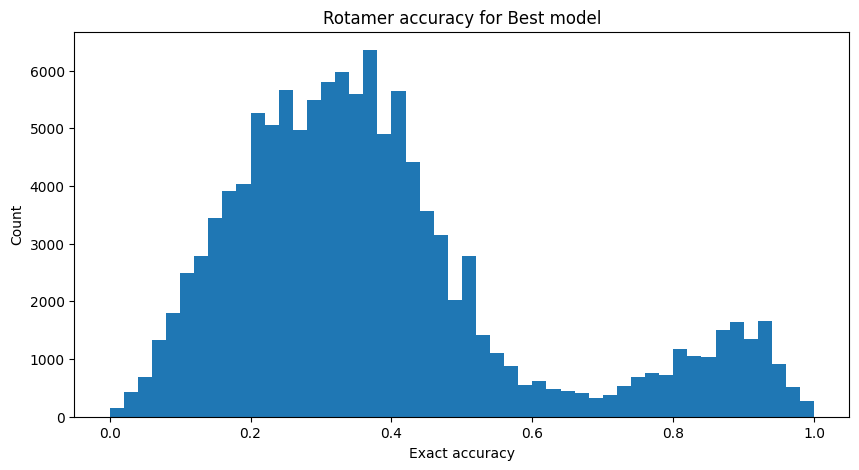

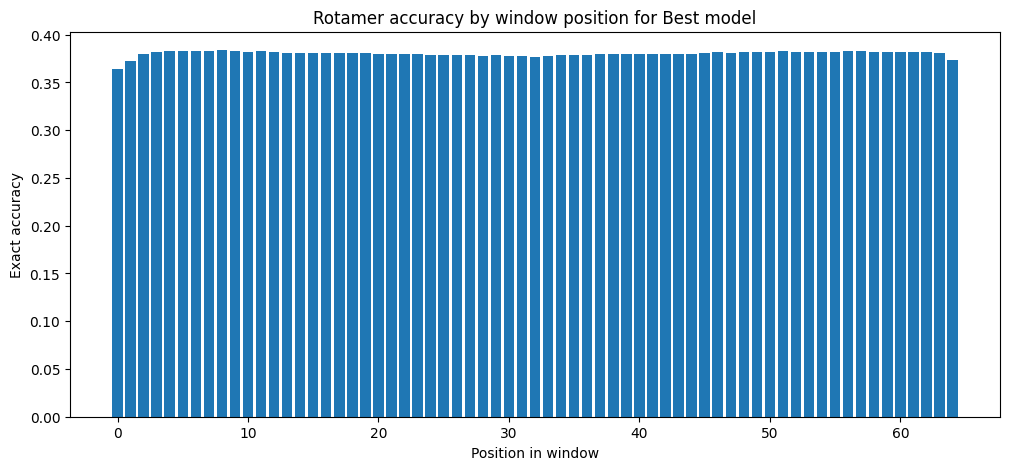

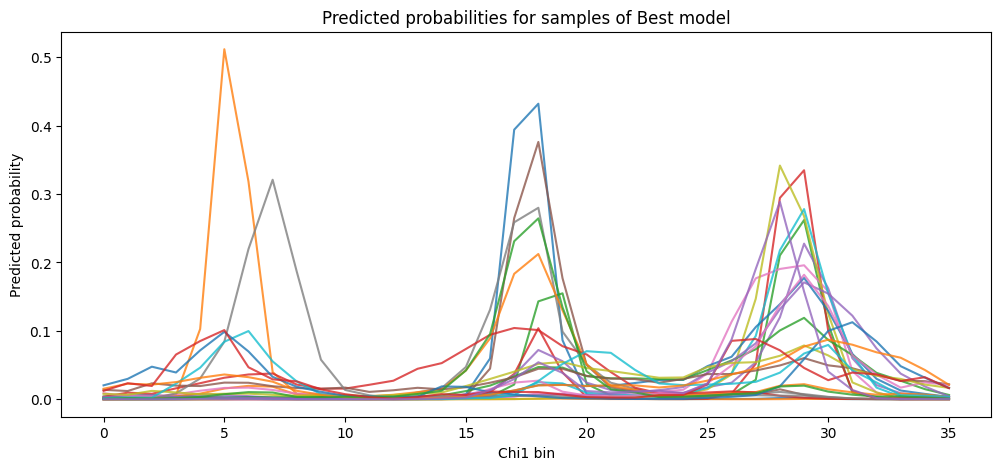

In [39]:
plot_model_diagnostics(
    diagnostics=best_model_diagnostics,
    model_name="Best model",
    metric_name="Exact accuracy",
    save_prefix="best_model",
)

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR = Path("data")
PROCESSED_DIR = DATA_DIR / "processed"
SPLIT_DIR = DATA_DIR / "splits"

residue_path = PROCESSED_DIR / "chi1_residue_level_dataset_with_backbone.csv"


residue_df = pd.read_csv(residue_path)

train_pdb_ids = set(pd.read_csv(SPLIT_DIR / "train_pdb_ids.csv")["pdb_id"])
val_pdb_ids = set(pd.read_csv(SPLIT_DIR / "val_pdb_ids.csv")["pdb_id"])
test_pdb_ids = set(pd.read_csv(SPLIT_DIR / "test_pdb_ids.csv")["pdb_id"])

splits = {
    "Train": train_pdb_ids,
    "Validation": val_pdb_ids,
    "Test": test_pdb_ids,
}

rows = []

WINDOW_SIZE = 65

for split_name, pdb_ids in splits.items():
    split_df = residue_df[residue_df["pdb_id"].isin(pdb_ids)].copy()

    n_pdb = split_df["pdb_id"].nunique()
    n_chains = split_df[["pdb_id", "chain_id"]].drop_duplicates().shape[0]
    n_rows = len(split_df)
    n_valid_targets = int(split_df["target_mask"].sum())
    n_invalid_targets = int((split_df["target_mask"] == 0).sum())

    rows.append({
        "Subset": split_name,
        "Number of PDB structures": n_pdb,
        "Number of chains": n_chains,
        "Residue-level rows": n_rows,
        "Number of windows": n_rows,
        "Valid chi1 targets": n_valid_targets,
        "Residues excluded from loss": n_invalid_targets,
        "Valid target rate": n_valid_targets / n_rows,
    })

stats_df = pd.DataFrame(rows)

stats_df

/var/folders/j3/qr5mg5rj55j5lf7yh978r__80000gn/T/ipykernel_12562/2172406200.py:13: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  residue_df = pd.read_csv(residue_path)


,Subset,Number of PDB structures,Number of chains,Residue-level rows,Number of windows,Valid chi1 targets,Residues excluded from loss,Valid target rate
0,Train,4874,4874,929004,929004,778895,150109,0.838419
1,Validation,609,609,113997,113997,95541,18456,0.838101
2,Test,610,610,118229,118229,99218,19011,0.839202


In [42]:
def compute_padding_statistics(split_df, window_size=65):
    radius = window_size // 2

    total_windows = 0
    total_padding_positions = 0

    for _, chain_df in split_df.groupby(["pdb_id", "chain_id"]):
        n = len(chain_df)
        total_windows += n

        for center_idx in range(n):
            left_missing = max(0, radius - center_idx)
            right_missing = max(0, center_idx + radius - (n - 1))
            total_padding_positions += left_missing + right_missing

    total_positions = total_windows * window_size
    padding_fraction = total_padding_positions / total_positions

    return total_padding_positions, padding_fraction


padding_rows = []

for split_name, pdb_ids in splits.items():
    split_df = residue_df[residue_df["pdb_id"].isin(pdb_ids)].copy()

    total_padding, padding_fraction = compute_padding_statistics(
        split_df,
        window_size=65,
    )

    padding_rows.append({
        "Subset": split_name,
        "Padding positions": total_padding,
        "Padding fraction": padding_fraction,
    })

padding_df = pd.DataFrame(padding_rows)
padding_df

,Subset,Padding positions,Padding fraction
0,Train,5146944,0.085235
1,Validation,643104,0.086791
2,Test,644160,0.083822


In [ ]:
###